## Creación del "Gold Standard" y Validación de Similitud Semántica

Los objetivos de este notebook son: realizar una extracción dirigida de una muestra estratificada de 50 medicamentos (N=50) que cubre el 80% de las casuísticas semánticas posibles; segmentar el texto y preparar un *Dataset* (aprox. 5600 frases) para su posterior anotación manual humana (0 = Irrelevante, 0.5 = Parcial, 1 = Relevante); validar si un modelo de *Sentence Embeddings* (SBERT) es capaz de discriminar automáticamente el contenido clínico valioso del "ruido" administrativo mediante Similitud del Coseno, calculando el umbral óptimo de corte (F1-Score).

### 1. Preparación del Entorno y Librerías
Importamos las herramientas de manipulación de datos, web scraping (`BeautifulSoup`), vectorización semántica (`SentenceTransformer`) y evaluación de modelos de Machine Learning (`sklearn.metrics`). 

Para la vectorización, utilizaremos el modelo SOTA multilingüe `paraphrase-multilingual-mpnet-base-v2`. A diferencia de modelos "crudos" (como RoBERTa), este ha sido entrenado usando *Siamese Networks*, lo que optimiza su espacio vectorial específicamente para que la distancia del coseno tenga un sentido semántico real.

In [1]:
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
import time
import re
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Muestreo Estratégico y Extracción desde CIMA
Para que la evaluación humana sea robusta, la muestra no puede ser aleatoria pura. Se ha diseñado un muestreo estratificado de 50 prospectos que abarca:
* **Alta prevalencia:** Analgésicos y antiinflamatorios top ventas (ej. Paracetamol, Ibuprofeno).
* **Crónicos y Cardiovasculares:** Patologías complejas con advertencias críticas de seguridad (ej. Sintrom).
* **Antibióticos:** Pautas de posología estrictas y limitadas en el tiempo.
* **Sistema Nervioso:** Advertencias específicas sobre conducción y adicción (ej. Lorazepam).
* **Formatos Especiales:** Inhaladores (Ventolín), pomadas o colirios, cuyas instrucciones físicas difieren ampliamente de la toma oral.

La clase `CimaFetcher` se encarga de extraer el HTML oficial, limpiar el ruido web y segmentar los párrafos respetando la puntuación gramatical.

In [2]:
# Clase para descargar del CIMA medicamentos concretos
class CimaFetcher:
    def __init__(self):
        self.base_url = "https://cima.aemps.es/cima/rest"
        # Títulos numéricos (Ej: "1. Qué es...") y de secciones típicas por si no las encuentra numéricamente
        self.patron_titulo_num = re.compile(r'^\d+\.\s+')
        self.titulos_oficiales = [
            "qué es", "antes de tomar", "cómo tomar", "posibles efectos", 
            "conservación", "contenido del envase", "información adicional"
        ]

    def es_titulo(self, texto, tag_name):
        """Devuelve True si el texto parece un título de sección."""
        texto_lower = texto.lower().strip()
        
        # 1. Por etiqueta HTML
        if tag_name in ['h1', 'h2', 'h3', 'h4']:
            return True
        
        # 2. Por patrón numérico ("1. Qué es...")
        if self.patron_titulo_num.match(texto) and len(texto) < 100:
            return True
            
        # 3. Por coincidencia con secciones oficiales (aunque esté en <p>) si es corto para no confundir con frases
        # que empiecen igual
        if len(texto) < 60 and any(oficial in texto_lower for oficial in self.titulos_oficiales):
            return True
            
        return False

    def limpiar_texto(self, texto):
        """Limpia espacios y normaliza."""
        texto = texto.replace('\xa0', ' ').replace('\r', '').replace('\n', ' ')
        return re.sub(r'\s+', ' ', texto).strip()

    def obtener_datos(self, nombre_medicamento):
        try:
            # 1. Buscar
            params = {'nombre': nombre_medicamento}
            r = requests.get(f"{self.base_url}/medicamentos", params=params)
            if r.status_code != 200: return None
            data = r.json()
            if data['totalFilas'] == 0: return None
            
            target_med = None
            url_prospecto = None
            for med in data['resultados']:
                if med.get('docs'):
                    for doc in med['docs']:
                        if doc['tipo'] == 2:
                            target_med = med
                            url_prospecto = doc['urlHtml']
                            break
                if target_med: break
            
            if not target_med: return None

            # 2. Descargar HTML
            r_html = requests.get(url_prospecto)
            soup = BeautifulSoup(r_html.content, 'html.parser')
            
            # 3. Extracción
            filas_excel = []
            seccion_actual = "Introducción / Sin Título"
            
            buffer_parrafo = "" # Aquí acumulamos frases rotas
            
            # Buscamos todo en orden
            elementos = soup.find_all(['h1', 'h2', 'h3', 'h4', 'p', 'li', 'div'])
            
            for elem in elementos:
                # Ignoramos divs contenedores, solo queremos texto final
                if elem.name == 'div' and elem.find(['p', 'h1', 'h2']): 
                    continue 

                texto_raw = elem.get_text(strip=True)
                texto_limpio = self.limpiar_texto(texto_raw)
                
                if not texto_limpio: continue

                # ¿Es un Título?
                if self.es_titulo(texto_limpio, elem.name):
                    # A) Si teníamos algo en el buffer, lo guardamos antes de cambiar de sección
                    if buffer_parrafo:
                        filas_excel.append({
                            'ID_Prospecto': target_med['nregistro'],
                            'Medicamento': target_med['nombre'],
                            'Titulo_Seccion': seccion_actual,
                            'Parrafo': buffer_parrafo,
                            'Es_Relevante': ''
                        })
                        buffer_parrafo = "" # Limpiamos buffer
                    
                    # B) Actualizamos título
                    seccion_actual = texto_limpio
                
                # Es contenido (párrafo o lista)
                else:
                    # ¿El buffer tiene cosas? Añadimos espacio
                    sep = " " if buffer_parrafo else ""
                    buffer_parrafo += sep + texto_limpio
                    
                    # Cortamos si termina en punto, cierre de interrogación/exclamación.
                    # O si es un elemento de lista (li), que suelen ser independientes.
                    if elem.name == 'li' or texto_limpio.endswith(('.', '?', '!')):
                        # GUARDAMOS Y LIMPIAMOS BUFFER
                        if len(buffer_parrafo) > 15: # Filtro de longitud mínima
                            filas_excel.append({
                                'ID_Prospecto': target_med['nregistro'],
                                'Medicamento': target_med['nombre'],
                                'Titulo_Seccion': seccion_actual,
                                'Parrafo': buffer_parrafo,
                                'Es_Relevante': ''
                            })
                        buffer_parrafo = ""
                    
                    # Si NO termina en punto, NO guardamos todavía. 
                    # El loop continúa y el siguiente trozo se pegará a 'buffer_parrafo'.

            # Al final del todo, si sobró algo en el buffer, lo guardamos
            if buffer_parrafo and len(buffer_parrafo) > 15:
                filas_excel.append({
                    'ID_Prospecto': target_med['nregistro'],
                    'Medicamento': target_med['nombre'],
                    'Titulo_Seccion': seccion_actual,
                    'Parrafo': buffer_parrafo,
                    'Es_Relevante': ''
                })
            
            return filas_excel

        except Exception as e:
            print(f"Error procesando {nombre_medicamento}: {e}")
            return None

In [3]:
# LISTA VARIADA DE 50 MEDICAMENTOS
lista_medicamentos = [
    # Analgesicos y Antiinflamatorios
    "Paracetamol Cinfa", "Ibuprofeno Kern Pharma", "Nolotil", "Enantyum", "Aspirina",
    "Voltaren", "Tramadol", "Dalsy", "Efferalgan", "Naproxeno",
    # Cronicos y Cardiovasculares
    "Sintrom", "Adiro 100", "Eutirox", "Simvastatina", "Atorvastatina",
    "Enalapril", "Losartan", "Bisoprolol", "Seguril", "Metformina",
    # Antibioticos
    "Amoxicilina Normon", "Augmentine", "Azitromicina", "Ciprofloxacino", "Monurol",
    # Salud Mental
    "Diazepam", "Lorazepam", "Alprazolam", "Lexatin", "Fluoxetina", "Escitalopram", "Lyrica",
    # Respiratorio y Alergias
    "Ventolin", "Ebastina", "Loratadina", "Flutox", "Mucosan",
    # Digestivo
    "Omeprazol", "Almax", "Aero red",
    # Formatos Especiales (Cremas, gotas, parches)
    "Thrombocid", "Fucidine", "Betadine", "Tobrex", "Synalar", "Canesten", "Durogesic",
    # Salud Sexual
    "Yasmin", "Viagra", "Cialis"
]

### 3. Vectorización Semántica y Cálculo de Similitud
Una vez que el dataset ha sido anotado manualmente por un experto humano (creando nuestro *Gold Standard*), procedemos a calcular la predicción con los embeddings.
El modelo transforma cada título de sección y cada párrafo en vectores densos. Posteriormente, aplicamos la **Similitud del Coseno**:

$$\text{Similitud}(A,B) = \cos(\theta) = \frac{A \cdot B}{||A|| ||B||}$$

El resultado es un valor continuo entre $0.0$ (ortogonal/sin relación) y $1.0$ (identidad semántica).

In [4]:
# EJECUCION
fetcher = CimaFetcher()
todos_los_datos = []

print(f"Iniciando descarga de {len(lista_medicamentos)} prospectos completos...")

for i, med in enumerate(lista_medicamentos):
    print(f"[{i+1}/{len(lista_medicamentos)}] Procesando: {med}...")
    datos = fetcher.obtener_datos(med)
    
    if datos:
        # Guardamos TODOS los parrafos
        todos_los_datos.extend(datos)
    else:
        print(f"  - No se encontraron datos para {med}")
    
    time.sleep(0.5) # Pequeña pausa para no saturar el servidor

Iniciando descarga de 50 prospectos completos...
[1/50] Procesando: Paracetamol Cinfa...
[2/50] Procesando: Ibuprofeno Kern Pharma...
[3/50] Procesando: Nolotil...
[4/50] Procesando: Enantyum...
[5/50] Procesando: Aspirina...
[6/50] Procesando: Voltaren...
[7/50] Procesando: Tramadol...
[8/50] Procesando: Dalsy...
[9/50] Procesando: Efferalgan...
[10/50] Procesando: Naproxeno...
[11/50] Procesando: Sintrom...
[12/50] Procesando: Adiro 100...
[13/50] Procesando: Eutirox...
[14/50] Procesando: Simvastatina...
[15/50] Procesando: Atorvastatina...
[16/50] Procesando: Enalapril...
[17/50] Procesando: Losartan...
[18/50] Procesando: Bisoprolol...
[19/50] Procesando: Seguril...
[20/50] Procesando: Metformina...
[21/50] Procesando: Amoxicilina Normon...
[22/50] Procesando: Augmentine...
[23/50] Procesando: Azitromicina...
[24/50] Procesando: Ciprofloxacino...
[25/50] Procesando: Monurol...
[26/50] Procesando: Diazepam...
[27/50] Procesando: Lorazepam...
[28/50] Procesando: Alprazolam...
[29/50

In [5]:
# Exportar excel para anotación manual
if todos_los_datos:
    df = pd.DataFrame(todos_los_datos)
    
    # Ordenar columnas
    columnas = ['ID_Prospecto', 'Medicamento', 'Titulo_Seccion', 'Parrafo', 'Es_Relevante']
    df = df[columnas]
    
    nombre_fichero = "validacion_manual_completa.xlsx"
    df.to_excel(nombre_fichero, index=False)
    
    print(f"\nProceso finalizado.")
    print(f"Archivo generado: {nombre_fichero}")
    print(f"Total de filas generadas: {len(df)}")
else:
    print("No se generaron datos.")


Proceso finalizado.
Archivo generado: validacion_manual_completa.xlsx
Total de filas generadas: 5636


### 4. Análisis Estadístico: Búsqueda del Umbral Óptimo
La similitud del coseno nos da un valor continuo, pero necesitamos una decisión binaria (Relevante vs. Irrelevante). Para encontrar el punto de corte óptimo, evaluamos la capacidad predictiva del modelo comparando sus similitudes contra las etiquetas humanas. 
Calculamos el **F1-Score** a lo largo de distintos umbrales para encontrar el equilibrio perfecto entre la *Precisión* (¿cuánta paja hemos colado?) y el *Recall* (¿cuánta información médica vital hemos perdido?).

Datos cargados: 4699 filas.
Distribución manual: {1: 3884, 0: 815}
Cargando modelo: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...
Generando embeddings...
Calculando distancias...

   RESULTADO DEL ANÁLISIS DE UMBRAL
MEJOR UMBRAL (Threshold): 0.0104
F1-Score conseguido:      0.9054
----------------------------------------
Matriz de Confusión:
Verdaderos Negativos (Modelo acierta que NO): 5
Falsos Positivos     (Modelo cree que sí, yo que no): 810
Falsos Negativos     (Modelo cree que no, yo que sí): 1
Verdaderos Positivos (Modelo acierta que SÍ): 3883


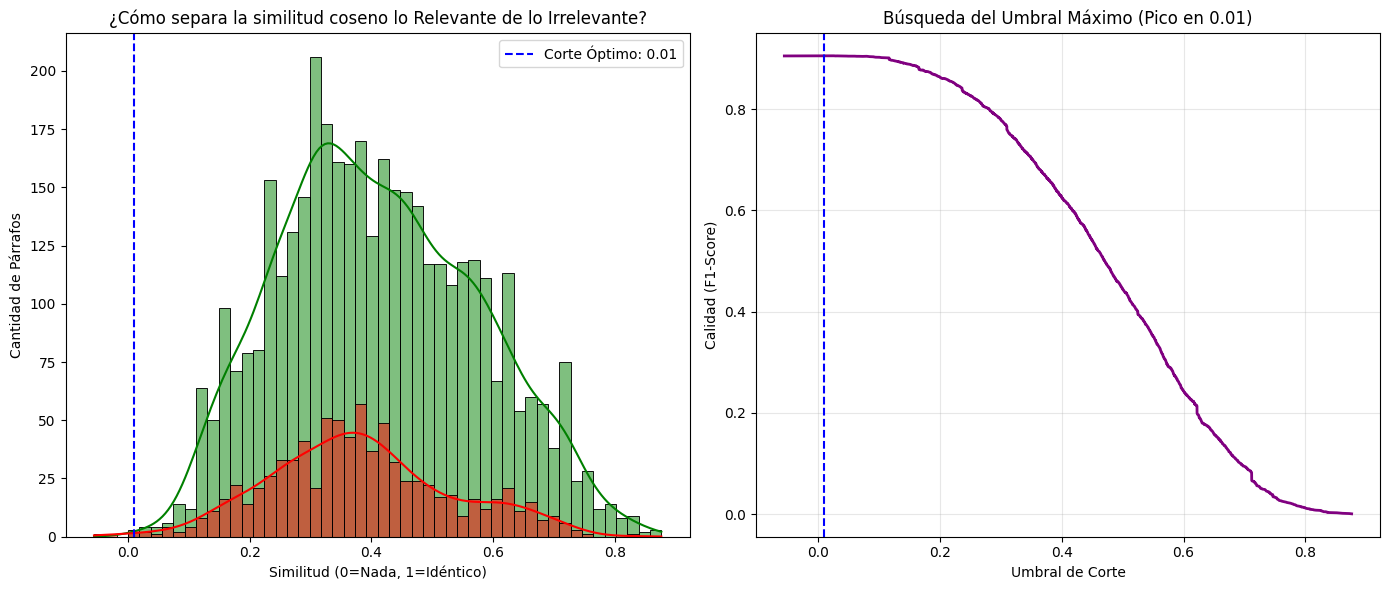


Archivo guardado: validacion_con_scores_mpnet.xlsx


In [ ]:
df = pd.read_excel("validacion_manual_completa.xlsx")
df.loc[df['Es_Relevante'] == 11, 'Es_Relevante'] = 1
# Limpieza básica
df = df.dropna(subset=['Es_Relevante'])
df['Es_Relevante'] = pd.to_numeric(df['Es_Relevante'], errors='coerce').fillna(0).astype(int)

print(f"Datos cargados: {len(df)} filas.")
print(f"Distribución manual: {df['Es_Relevante'].value_counts().to_dict()}")

# Embeddings
model_name = 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'
print(f"Cargando modelo: {model_name}...")
model = SentenceTransformer(model_name)

# Codificamos Títulos y Párrafos
print("Generando embeddings...")
embeddings_titulos = model.encode(df['Titulo_Seccion'].astype(str).tolist(), convert_to_tensor=True)
embeddings_parrafos = model.encode(df['Parrafo'].astype(str).tolist(), convert_to_tensor=True)

# Similitud coseno
# Calculamos la similitud par a par (Fila 1 con Fila 1, Fila 2 con Fila 2...)
# util.cos_sim devuelve una matriz, cogemos la diagonal que corresponde a los pares
print("Calculando distancias...")
similitudes = [util.cos_sim(t, p).item() for t, p in zip(embeddings_titulos, embeddings_parrafos)]
df['Similitud'] = similitudes

# Umbral óptimo
# Probamos miles de umbrales para ver cuál maximiza el F1-Score (Equilibrio aciertos)
precision, recall, thresholds = precision_recall_curve(df['Es_Relevante'], df['Similitud'])

# F1 = 2 * (Precision * Recall) / (Precision + Recall)
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores) # Quitar nulos si hay división por 0

# Buscamos el mejor
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("\n" + "="*40)
print(f"   RESULTADO DEL ANÁLISIS DE UMBRAL")
print("="*40)
print(f"MEJOR UMBRAL (Threshold): {best_threshold:.4f}")
print(f"F1-Score conseguido:      {best_f1:.4f}")
print("-" * 40)

# Aplicamos el umbral para ver la matriz de confusión
df['Prediccion'] = (df['Similitud'] >= best_threshold).astype(int)
matriz = confusion_matrix(df['Es_Relevante'], df['Prediccion'])

print("Matriz de Confusión:")
print(f"Verdaderos Negativos (Modelo acierta que NO): {matriz[0][0]}")
print(f"Falsos Positivos     (Modelo cree que sí, yo que no): {matriz[0][1]}")
print(f"Falsos Negativos     (Modelo cree que no, yo que sí): {matriz[1][0]}")
print(f"Verdaderos Positivos (Modelo acierta que SÍ): {matriz[1][1]}")

# Gráficos
plt.figure(figsize=(14, 6))

# Gráfico 1: Histograma de Similitudes
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Similitud', hue='Es_Relevante', bins=50, kde=True, palette={0: 'red', 1: 'green'})
plt.axvline(best_threshold, color='blue', linestyle='--', label=f'Corte Óptimo: {best_threshold:.2f}')
plt.title('¿Cómo separa la similitud coseno lo Relevante de lo Irrelevante?')
plt.xlabel('Similitud (0=Nada, 1=Idéntico)')
plt.ylabel('Cantidad de Párrafos')
plt.legend()

# Gráfico 2: Curva de Optimización
plt.subplot(1, 2, 2)
plt.plot(thresholds, f1_scores[:-1], color='purple', linewidth=2)
plt.axvline(best_threshold, color='blue', linestyle='--')
plt.title(f'Búsqueda del Umbral Máximo (Pico en {best_threshold:.2f})')
plt.xlabel('Umbral de Corte')
plt.ylabel('Calidad (F1-Score)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_umbral_embeddings.png')
plt.show()


df.to_excel("validacion_con_scores_mpnet.xlsx", index=False)
print("\nArchivo guardado: validacion_con_scores_mpnet.xlsx")

### 5. Visualización de Resultados y Evaluación de la Señal Discriminatoria
El análisis visual de las distribuciones de similitud (Boxplot y Curva ROC) confirma que existe cierta señal discriminatoria, pero con un alto grado de solapamiento entre los párrafos relevantes e irrelevantes. 

A la vista de estos gráficos, **los resultados de aplicar un umbral de corte estático son no concluyentes** para establecer un clasificador binario robusto (AUC de 0.57). Este hallazgo empírico justifica la necesidad de abandonar la clasificación basada en umbrales simples y evolucionar hacia el uso de métricas combinadas (F1-Score óptimo) y técnicas de aprendizaje no supervisado (Topic Modeling y Clustering) para reestructurar la información del prospecto con mayor precisión.